# 06 - Advanced Graph RAG

Questo notebook documenta il processo dello step 06 con tre obiettivi pratici:

1. mostrare, su un caso controllato ma realistico, come cambiano i chunk tra retrieval, graph expansion, rerank e contesto finale;
2. confrontare un comportamento `simple-like` con la pipeline advanced usando gli stessi input;
3. lanciare opzionalmente la full run sui 100 record MCQ e 100 record no-hint, poi visualizzare le performance con matplotlib.

La parte dimostrativa non usa credenziali Utopia: Qdrant gira in memoria, l'embedder e il client strutturato sono fake controllati. La full run reale resta in fondo e va attivata esplicitamente.


**Setup.** Importa dipendenze, risolve la root del repository e configura modelli/env usati dalle celle successive.


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
import tempfile
from threading import Lock
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from qdrant_client import QdrantClient
from qdrant_client.http import models as qmodels

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = next(path for path in ROOT.parents if (path / "src").exists())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from legal_rag.advanced_graph_rag import (
    AdvancedRagConfig,
    UtopiaStructuredChatClient,
    build_advanced_query_embedder,
    connect_qdrant,
    load_index_manifest,
    resolve_answer_model,
    resolve_collection_name,
    resolve_judge_model,
    resolve_qdrant_target,
    resolve_utopia_runtime,
    run_advanced_graph_rag,
    validate_qdrant_collection_ready,
)
from legal_rag.oracle_context_evaluation.io import sha256_file, write_json, write_jsonl
from legal_rag.oracle_context_evaluation.models import DEFAULT_CHAT_MODEL

CHAT_MODEL = os.getenv("UTOPIA_CHAT_MODEL") or DEFAULT_CHAT_MODEL
JUDGE_MODEL = os.getenv("UTOPIA_JUDGE_MODEL") or None

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True, "grid.alpha": 0.25})
ROOT


PosixPath('/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite')

## Pipeline

La pipeline advanced non cambia il contratto di valutazione rispetto al simple RAG: cambia solo il modo in cui si costruisce il contesto. Ogni passaggio lascia traccia nei JSONL di output. Il diagramma viene disegnato nella cella successiva con matplotlib, così resta renderizzabile anche in ambienti Jupyter senza estensione Mermaid.


**Diagramma pipeline.** Visualizza i passaggi principali dell'advanced RAG senza dipendere dal renderer Mermaid.


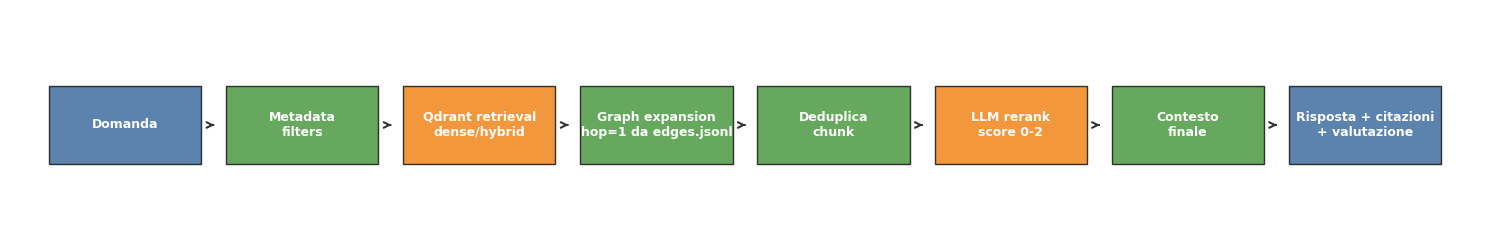

In [14]:
pipeline_steps = [
    "Domanda",
    "Metadata\nfilters",
    "Qdrant retrieval\ndense/hybrid",
    "Graph expansion\nhop=1 da edges.jsonl",
    "Deduplica\nchunk",
    "LLM rerank\nscore 0-2",
    "Contesto\nfinale",
    "Risposta + citazioni\n+ valutazione",
]

fig, ax = plt.subplots(figsize=(15, 2.6))
ax.axis("off")

x_positions = list(range(len(pipeline_steps)))
y = 0.5
box_width = 0.86
box_height = 0.34

for idx, label in enumerate(pipeline_steps):
    color = "#4e79a7" if idx in {0, 7} else "#f28e2b" if idx in {2, 5} else "#59a14f"
    rect = plt.Rectangle(
        (idx - box_width / 2, y - box_height / 2),
        box_width,
        box_height,
        facecolor=color,
        edgecolor="#222222",
        linewidth=1.0,
        alpha=0.92,
    )
    ax.add_patch(rect)
    ax.text(idx, y, label, ha="center", va="center", color="white", fontsize=9, weight="bold")
    if idx < len(pipeline_steps) - 1:
        ax.annotate(
            "",
            xy=(idx + 1 - box_width / 2 - 0.05, y),
            xytext=(idx + box_width / 2 + 0.05, y),
            arrowprops={"arrowstyle": "->", "lw": 1.5, "color": "#333333"},
        )

ax.set_xlim(-0.65, len(pipeline_steps) - 0.35)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Caso dimostrativo

Il caso è costruito per riprodurre un problema tipico: il retrieval vettoriale trova una legge seed pertinente, ma la risposta sta in una legge collegata da un riferimento esplicito. Il simple-like RAG vede solo il seed e sbaglia; l'advanced RAG segue l'edge, aggiunge il chunk target e il rerank lo porta nel contesto.


**Dati demo.** Definisce leggi, chunk e relazioni minimali per mostrare il comportamento del graph RAG senza servizi esterni.


In [2]:
LAW_SEED = "vda:lr:2024-01-15:10"
LAW_TARGET = "vda:lr:2024-02-10:11"
LAW_NOISE = "vda:lr:2023-12-20:9"
ANSWER_CHUNK_ID = "chunk_target_answer"

LAW_TITLES = {
    LAW_SEED: "Legge regionale 15 gennaio 2024, n. 10 - Misure per contributi comunali",
    LAW_TARGET: "Legge regionale 10 febbraio 2024, n. 11 - Disciplina attuativa dei termini",
    LAW_NOISE: "Legge regionale 20 dicembre 2023, n. 9 - Disposizioni generali",
}


def chunk_payload(chunk_id: str, *, law_id: str, article_label: str, text: str) -> dict[str, Any]:
    return {
        "chunk_id": chunk_id,
        "law_id": law_id,
        "article_id": f"{law_id}#art:{article_label}",
        "article_label_norm": article_label,
        "text": text,
        "law_title": LAW_TITLES[law_id],
        "law_status": "current",
        "article_status": "current",
        "index_views": ["current"],
        "relation_types": [],
    }


DEMO_PAYLOADS = [
    chunk_payload(
        "chunk_seed_retrieved",
        law_id=LAW_SEED,
        article_label="2",
        text="La domanda di contributo e' disciplinata dalla legge attuativa richiamata dalla presente legge.",
    ),
    chunk_payload(
        ANSWER_CHUNK_ID,
        law_id=LAW_TARGET,
        article_label="3",
        text="La domanda di contributo deve essere presentata entro trenta giorni dalla pubblicazione dell'avviso.",
    ),
    chunk_payload(
        "chunk_noise",
        law_id=LAW_NOISE,
        article_label="1",
        text="Disposizione generale non utile per il termine di presentazione della domanda.",
    ),
]

DEMO_QUESTION = "Entro quale termine deve essere presentata la domanda di contributo?"
DEMO_EXPECTED_REFERENCE = "Legge regionale 10 febbraio 2024, n. 11 - Art. 3"


**Fake runtime.** Crea embedder, client LLM e helper Qdrant controllati per una demo riproducibile e veloce.


In [3]:
class DemoHybridEmbedder:
    @property
    def model_name(self) -> str:
        return "demo-bge-m3-like"

    def embed_texts(self, texts: list[str]) -> list[list[float]]:
        # The query is intentionally closer to the seed chunk than to the answer chunk.
        return [[1.0, 0.0, 0.0, 0.0] for _ in texts]

    def embed_sparse_texts(self, texts: list[str]) -> list[dict[str, list[int] | list[float]]]:
        return [{"indices": [101], "values": [1.0]} for _ in texts]


class DemoStructuredClient:
    def structured_chat(self, *, prompt: str, model: str, payload_schema: dict[str, Any], timeout_seconds: int) -> dict[str, Any]:
        properties = payload_schema.get("properties", {})
        context_ids = re.findall(r"chunk_id: ([^\s]+)", prompt)
        has_answer_chunk = ANSWER_CHUNK_ID in context_ids

        if "scores" in properties:
            scores = []
            for chunk_id in context_ids:
                scores.append({"chunk_id": chunk_id, "score": 2 if chunk_id == ANSWER_CHUNK_ID else 0})
            return {"structured": {"scores": scores}}

        citation = ANSWER_CHUNK_ID if has_answer_chunk else (context_ids[0] if context_ids else "chunk_seed_retrieved")
        if "answer_label" in properties:
            return {"structured": {"answer_label": "A" if has_answer_chunk else "B", "citation_chunk_ids": [citation], "short_rationale": "demo"}}
        if "answer_text" in properties:
            text = "Entro trenta giorni dalla pubblicazione dell'avviso." if has_answer_chunk else "Il contesto non contiene il termine esatto."
            return {"structured": {"answer_text": text, "citation_chunk_ids": [citation], "short_rationale": "demo"}}
        if "score" in properties:
            return {"structured": {"score": 2 if "trenta giorni" in prompt else 0, "explanation": "Valutazione demo controllata."}}
        raise AssertionError(payload_schema)


**File demo.** Scrive dataset, chunk, edge e manifest temporanei richiesti dalla pipeline advanced.


In [4]:
def build_demo_files(root: Path) -> tuple[Path, Path, Path, Path]:
    evaluation_dir = root / "evaluation_clean"
    laws_dir = root / "laws_dataset_clean"
    evaluation_dir.mkdir(parents=True)
    laws_dir.mkdir(parents=True)

    mcq = [{
        "qid": "demo-advanced-0001",
        "source_position": 1,
        "level": "L2",
        "question_stem": DEMO_QUESTION,
        "options": {
            "A": "Entro trenta giorni dalla pubblicazione dell'avviso.",
            "B": "Entro sessanta giorni dalla pubblicazione dell'avviso.",
            "C": "Entro il 31 dicembre dell'anno di riferimento.",
            "D": "Prima della deliberazione della Giunta.",
            "E": "Senza termine espresso.",
            "F": "Entro dieci giorni dalla domanda.",
        },
        "correct_label": "A",
        "correct_answer": "Entro trenta giorni dalla pubblicazione dell'avviso.",
        "expected_references": [DEMO_EXPECTED_REFERENCE],
    }]
    no_hint = [{
        "qid": "demo-advanced-0001",
        "source_position": 1,
        "level": "L2",
        "question": DEMO_QUESTION,
        "correct_answer": "Entro trenta giorni dalla pubblicazione dell'avviso.",
        "expected_references": [DEMO_EXPECTED_REFERENCE],
        "linked_mcq_qid": "demo-advanced-0001",
    }]
    write_jsonl(evaluation_dir / "questions_mcq.jsonl", mcq)
    write_jsonl(evaluation_dir / "questions_no_hint.jsonl", no_hint)
    write_json(evaluation_dir / "evaluation_manifest.json", {"schema_version": "evaluation-dataset-v1", "records": 1})

    write_jsonl(laws_dir / "laws.jsonl", [{"law_id": law_id, "law_title": title} for law_id, title in LAW_TITLES.items()])
    write_jsonl(laws_dir / "articles.jsonl", [
        {"law_id": LAW_SEED, "article_id": f"{LAW_SEED}#art:2", "article_label_norm": "2", "article_text": DEMO_PAYLOADS[0]["text"]},
        {"law_id": LAW_TARGET, "article_id": f"{LAW_TARGET}#art:3", "article_label_norm": "3", "article_text": DEMO_PAYLOADS[1]["text"]},
        {"law_id": LAW_NOISE, "article_id": f"{LAW_NOISE}#art:1", "article_label_norm": "1", "article_text": DEMO_PAYLOADS[2]["text"]},
    ])
    write_jsonl(laws_dir / "edges.jsonl", [{"edge_id": "edge-seed-target", "src_law_id": LAW_SEED, "dst_law_id": LAW_TARGET, "relation_type": "REFERENCES"}])
    write_jsonl(laws_dir / "chunks.jsonl", DEMO_PAYLOADS)
    write_json(laws_dir / "manifest.json", {"ready_for_indexing": True})

    index_manifest = root / "indexing_runs" / "demo" / "index_manifest.json"
    index_manifest.parent.mkdir(parents=True)
    write_json(index_manifest, {
        "schema_version": "indexing-contract-v1",
        "collection_name": "advanced_demo",
        "ready_for_retrieval": True,
        "hybrid_enabled": True,
        "embedding": {"provider": "demo", "model": "demo-bge-m3-like", "configured_model": "demo-bge-m3-like", "mode": "dense+sparse"},
        "config": {"embedding_provider": "demo", "embedding_model": "demo-bge-m3-like", "hybrid_enabled": True},
    })

    simple_manifest = root / "simple" / "simple_rag_manifest.json"
    simple_manifest.parent.mkdir(parents=True)
    write_json(simple_manifest, {"schema_version": "simple-rag-v1", "source_hashes": {
        "questions_mcq": sha256_file(evaluation_dir / "questions_mcq.jsonl"),
        "questions_no_hint": sha256_file(evaluation_dir / "questions_no_hint.jsonl"),
        "evaluation_manifest": sha256_file(evaluation_dir / "evaluation_manifest.json"),
        "index_manifest": sha256_file(index_manifest),
    }})
    return evaluation_dir, laws_dir, index_manifest, simple_manifest


def build_demo_qdrant() -> QdrantClient:
    client = QdrantClient(":memory:")
    client.create_collection(
        collection_name="advanced_demo",
        vectors_config={"dense": qmodels.VectorParams(size=4, distance=qmodels.Distance.COSINE)},
        sparse_vectors_config={"sparse": qmodels.SparseVectorParams()},
    )
    vectors = [
        {"dense": [1.0, 0.0, 0.0, 0.0], "sparse": qmodels.SparseVector(indices=[101], values=[1.0])},
        {"dense": [0.2, 0.8, 0.0, 0.0], "sparse": qmodels.SparseVector(indices=[303], values=[1.0])},
        {"dense": [0.85, 0.15, 0.0, 0.0], "sparse": qmodels.SparseVector(indices=[909], values=[1.0])},
    ]
    points = [qmodels.PointStruct(id=idx, vector=vector, payload=payload) for idx, (vector, payload) in enumerate(zip(vectors, DEMO_PAYLOADS), start=1)]
    client.upsert(collection_name="advanced_demo", points=points, wait=True)
    return client


**Utility lettura.** Carica artifact JSON/JSONL e compatta le trace per ispezionare retrieval, graph expansion e rerank.


In [5]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.exists():
        return []
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def load_run(run_dir: Path) -> dict[str, Any]:
    return {
        "dir": run_dir,
        "summary": read_json(run_dir / "advanced_rag_summary.json"),
        "diagnostics": read_json(run_dir / "advanced_diagnostics.json"),
        "mcq": read_jsonl(run_dir / "mcq_results.jsonl"),
        "no_hint": read_jsonl(run_dir / "no_hint_results.jsonl"),
    }


def metric(summary: dict[str, Any], dataset: str, key: str) -> float:
    value = summary.get(dataset, {}).get(key, 0)
    return float(value or 0)


def run_has_total_errors(summary: dict[str, Any]) -> bool:
    datasets = [summary.get("mcq", {}), summary.get("no_hint", {})]
    return all(int(item.get("processed") or 0) > 0 and int(item.get("errors") or 0) >= int(item.get("processed") or 0) for item in datasets)


def compact_trace(row: dict[str, Any]) -> dict[str, Any]:
    return {key: row.get(key) for key in [
        "qid", "predicted_label", "score", "judge_score", "retrieval_mode", "retrieved_chunk_ids",
        "graph_expanded_chunk_ids", "graph_relations_used", "reranked_chunk_ids", "rerank_scores",
        "context_chunk_ids", "context_sufficient", "reference_law_hit", "failure_category", "error",
    ] if key in row}


def show_trace_table(title: str, row: dict[str, Any]) -> None:
    stage_by_chunk: dict[str, list[str]] = {}
    for chunk_id in row.get("retrieved_chunk_ids", []):
        stage_by_chunk.setdefault(chunk_id, []).append("retrieved")
    for chunk_id in row.get("graph_expanded_chunk_ids", []):
        stage_by_chunk.setdefault(chunk_id, []).append("graph")
    for chunk_id in row.get("reranked_chunk_ids", []):
        stage_by_chunk.setdefault(chunk_id, []).append("reranked")
    for chunk_id in row.get("context_chunk_ids", []):
        stage_by_chunk.setdefault(chunk_id, []).append("context")

    lines = [f"### {title}", "", "| chunk_id | fasi |", "|---|---|"]
    for chunk_id, stages in stage_by_chunk.items():
        lines.append(f"| `{chunk_id}` | {', '.join(stages)} |")
    display(Markdown(chr(10).join(lines)))


## Simple-like vs advanced sulla demo

La prima run disattiva graph expansion e rerank: è una proxy del simple RAG perché recupera solo dense top-k e passa direttamente quel contesto al modello. La seconda attiva retrieval hybrid, espansione graph-aware e rerank.


**Run demo.** Esegue due configurazioni sulla stessa domanda: una simple-like e una advanced con graph expansion e rerank.


In [6]:
demo_root = Path(tempfile.mkdtemp(prefix="advanced-rag-notebook-"))
evaluation_dir, laws_dir, index_manifest, simple_manifest = build_demo_files(demo_root)
base_demo_config = {
    "evaluation_dir": str(evaluation_dir),
    "laws_dir": str(laws_dir),
    "index_manifest_path": str(index_manifest),
    "simple_rag_manifest_path": str(simple_manifest),
    "output_root": str(demo_root / "advanced_runs"),
    "chat_model": "demo-answer",
    "judge_model": "demo-judge",
    "max_concurrency": 1,
    "top_k": 1,
    "graph_expansion_seed_k": 1,
    "max_chunks_per_expanded_law": 1,
    "max_expanded_chunks_total": 3,
    "min_edge_confidence": 0.45,
    "rerank_input_k": 3,
    "rerank_output_k": 2,
}

simple_like_manifest = run_advanced_graph_rag(
    AdvancedRagConfig(**base_demo_config, run_name="demo_simple_like", hybrid_enabled=False, graph_expansion_enabled=False, rerank_enabled=False),
    client=DemoStructuredClient(),
    qdrant_client=build_demo_qdrant(),
    embedder=DemoHybridEmbedder(),
)
advanced_manifest = run_advanced_graph_rag(
    AdvancedRagConfig(**base_demo_config, run_name="demo_advanced_all_on", hybrid_enabled=True, graph_expansion_enabled=True, rerank_enabled=True),
    client=DemoStructuredClient(),
    qdrant_client=build_demo_qdrant(),
    embedder=DemoHybridEmbedder(),
)

simple_like_run = load_run(Path(simple_like_manifest["config"]["output_dir"]))
advanced_demo_run = load_run(Path(advanced_manifest["config"]["output_dir"]))

simple_row = simple_like_run["mcq"][0]
advanced_row = advanced_demo_run["mcq"][0]
compact_trace(simple_row), compact_trace(advanced_row)


({'qid': 'demo-advanced-0001',
  'predicted_label': 'B',
  'score': 0,
  'retrieval_mode': 'dense',
  'retrieved_chunk_ids': ['chunk_seed_retrieved'],
  'graph_expanded_chunk_ids': [],
  'graph_relations_used': [],
  'reranked_chunk_ids': ['chunk_seed_retrieved'],
  'rerank_scores': [],
  'context_chunk_ids': ['chunk_seed_retrieved'],
  'reference_law_hit': False,
  'failure_category': 'context_noise',
  'error': None},
 {'qid': 'demo-advanced-0001',
  'predicted_label': 'A',
  'score': 1,
  'retrieval_mode': 'hybrid',
  'retrieved_chunk_ids': ['chunk_seed_retrieved', 'chunk_target_answer'],
  'graph_expanded_chunk_ids': ['chunk_target_answer'],
  'graph_relations_used': [{'relation_type': 'REFERENCES',
    'source_law_id': 'vda:lr:2024-01-15:10',
    'target_law_id': 'vda:lr:2024-02-10:11'}],
  'reranked_chunk_ids': ['chunk_target_answer', 'chunk_seed_retrieved'],
  'rerank_scores': [2, 0],
  'context_chunk_ids': ['chunk_target_answer', 'chunk_seed_retrieved'],
  'reference_law_hit': 

**Trace demo.** Visualizza quali chunk entrano in retrieval, graph expansion, rerank e contesto finale.


### Traccia simple-like

| chunk_id | fasi |
|---|---|
| `chunk_seed_retrieved` | retrieved, reranked, context |

### Traccia advanced

| chunk_id | fasi |
|---|---|
| `chunk_seed_retrieved` | retrieved, reranked, context |
| `chunk_target_answer` | retrieved, graph, reranked, context |

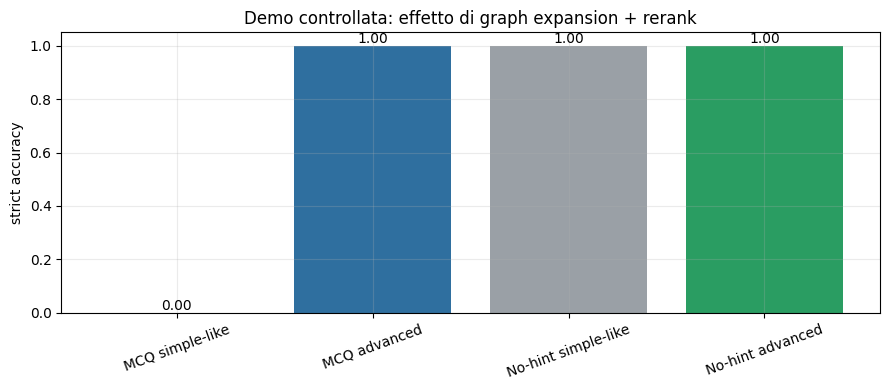

In [7]:
show_trace_table("Traccia simple-like", simple_row)
show_trace_table("Traccia advanced", advanced_row)

labels = ["MCQ simple-like", "MCQ advanced", "No-hint simple-like", "No-hint advanced"]
values = [
    metric(simple_like_run["summary"], "mcq", "strict_accuracy"),
    metric(advanced_demo_run["summary"], "mcq", "strict_accuracy"),
    metric(simple_like_run["summary"], "no_hint", "strict_accuracy"),
    metric(advanced_demo_run["summary"], "no_hint", "strict_accuracy"),
]
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#9aa0a6", "#2f6f9f", "#9aa0a6", "#2a9d62"]
ax.bar(labels, values, color=colors)
ax.set_ylim(0, 1.05)
ax.set_ylabel("strict accuracy")
ax.set_title("Demo controllata: effetto di graph expansion + rerank")
ax.tick_params(axis="x", rotation=20)
ax.bar_label(ax.containers[0], fmt="%.2f")
plt.tight_layout()
plt.show()


## Lettura del processo

Nel caso demo il retrieval iniziale trova `chunk_seed_retrieved`: è semanticamente vicino alla domanda, ma non contiene il termine richiesto. La graph expansion usa l'edge esplicito `LAW_SEED -> LAW_TARGET` e aggiunge `chunk_target_answer`. Il rerank assegna score massimo al chunk target e lo fa entrare nel contesto finale.


**Conteggi processo.** Riassume in grafico quanto cambia il numero di chunk tra simple-like e advanced.


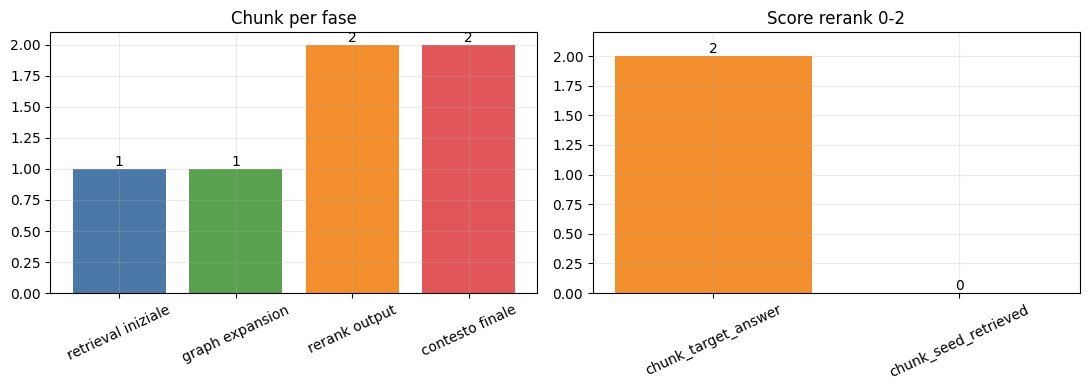

[{'relation_type': 'REFERENCES',
  'source_law_id': 'vda:lr:2024-01-15:10',
  'target_law_id': 'vda:lr:2024-02-10:11'}]

In [8]:
process_counts = {
    "retrieval iniziale": len(set(advanced_row["retrieved_chunk_ids"]) - set(advanced_row["graph_expanded_chunk_ids"])),
    "graph expansion": len(advanced_row["graph_expanded_chunk_ids"]),
    "rerank output": len(advanced_row["reranked_chunk_ids"]),
    "contesto finale": len(advanced_row["context_chunk_ids"]),
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(process_counts.keys(), process_counts.values(), color=["#4c78a8", "#59a14f", "#f28e2b", "#e15759"])
axes[0].set_title("Chunk per fase")
axes[0].tick_params(axis="x", rotation=25)
axes[0].bar_label(axes[0].containers[0])

rerank_ids = advanced_row["reranked_chunk_ids"]
rerank_scores = advanced_row["rerank_scores"]
axes[1].bar(rerank_ids, rerank_scores, color="#f28e2b")
axes[1].set_ylim(0, 2.2)
axes[1].set_title("Score rerank 0-2")
axes[1].tick_params(axis="x", rotation=25)
axes[1].bar_label(axes[1].containers[0])
plt.tight_layout()
plt.show()

advanced_row["graph_relations_used"]


## Artifact esistenti nel workspace

Questa sezione legge i risultati già generati, se presenti. Serve per confrontare lo step 06 con il simple RAG dello step 05 e per ispezionare eventuali run advanced o ablation già disponibili.


**Caricamento run.** Legge i summary simple/no-context/advanced già presenti nel workspace, scartando run completamente in errore.


In [9]:
SIMPLE_SUMMARY_PATH = ROOT / "data/rag_runs/simple/simple_rag_summary.json"
ADVANCED_ROOT = ROOT / "data/rag_runs/advanced"

simple_summary = read_json(SIMPLE_SUMMARY_PATH) if SIMPLE_SUMMARY_PATH.exists() else None
advanced_runs = []
if ADVANCED_ROOT.exists():
    for run_dir in sorted(path for path in ADVANCED_ROOT.iterdir() if path.is_dir()):
        summary_path = run_dir / "advanced_rag_summary.json"
        diagnostics_path = run_dir / "advanced_diagnostics.json"
        if summary_path.exists() and diagnostics_path.exists():
            summary = read_json(summary_path)
            diagnostics = read_json(diagnostics_path)
            status = "all_errors" if run_has_total_errors(summary) else "usable"
            advanced_runs.append((run_dir.name, summary, diagnostics, status))

usable_advanced_runs = [item for item in advanced_runs if item[3] == "usable"]
print(f"simple summary trovato: {bool(simple_summary)}")
print(f"advanced run utilizzabili: {[name for name, _, _, _ in usable_advanced_runs]}")
print(f"advanced run con tutti i record in errore: {[name for name, _, _, status in advanced_runs if status != 'usable']}")


simple summary trovato: True
advanced run utilizzabili: ['full_100_dense_graph_rerank']
advanced run con tutti i record in errore: ['smoke_dense_graph_rerank']


**Confronto globale.** Costruisce una tabella delle metriche principali tra baseline e advanced disponibili.


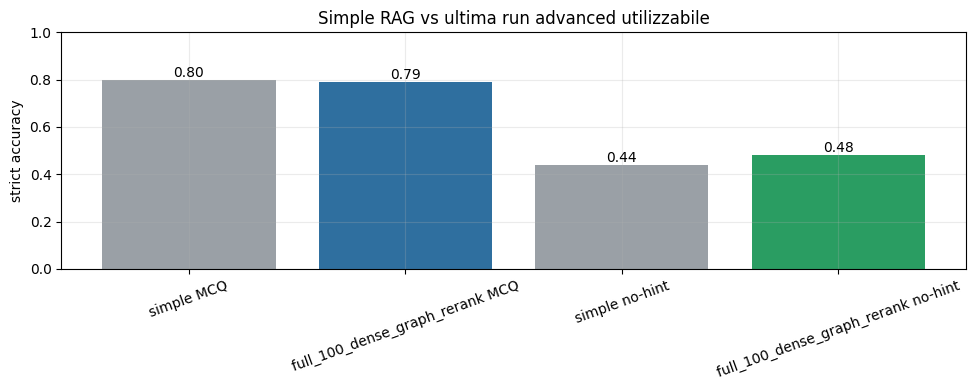

In [10]:
if simple_summary and usable_advanced_runs:
    latest_name, latest_summary, _, _ = usable_advanced_runs[-1]
    labels = ["simple MCQ", f"{latest_name} MCQ", "simple no-hint", f"{latest_name} no-hint"]
    values = [
        metric(simple_summary, "mcq", "strict_accuracy"),
        metric(latest_summary, "mcq", "strict_accuracy"),
        metric(simple_summary, "no_hint", "strict_accuracy"),
        metric(latest_summary, "no_hint", "strict_accuracy"),
    ]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, values, color=["#9aa0a6", "#2f6f9f", "#9aa0a6", "#2a9d62"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("strict accuracy")
    ax.set_title("Simple RAG vs ultima run advanced utilizzabile")
    ax.tick_params(axis="x", rotation=20)
    ax.bar_label(ax.containers[0], fmt="%.2f")
    plt.tight_layout()
    plt.show()
elif simple_summary:
    print("Trovato simple RAG, ma nessuna run advanced utilizzabile. Le run all_errors vanno rigenerate.")
else:
    print("Nessun simple_rag_summary.json trovato.")


**Grafico baseline.** Mostra la strict accuracy per MCQ e no-hint sulle run usabili.


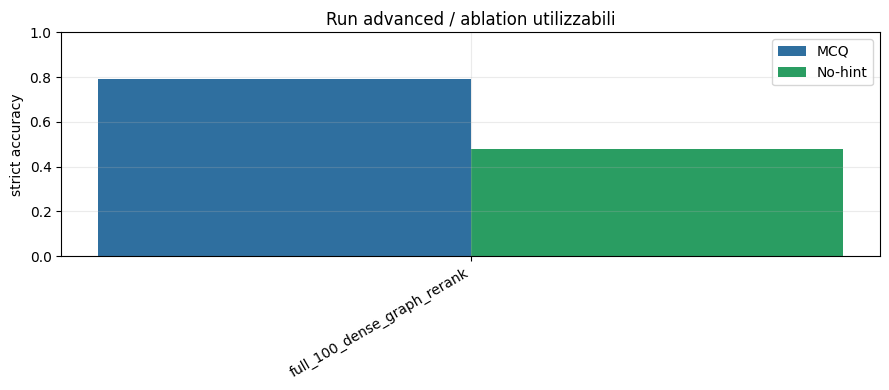

In [11]:
if usable_advanced_runs:
    names = [name for name, _, _, _ in usable_advanced_runs]
    mcq_values = [metric(summary, "mcq", "strict_accuracy") for _, summary, _, _ in usable_advanced_runs]
    no_hint_values = [metric(summary, "no_hint", "strict_accuracy") for _, summary, _, _ in usable_advanced_runs]
    x = list(range(len(names)))
    fig, ax = plt.subplots(figsize=(max(9, len(names) * 1.25), 4))
    ax.bar([i - 0.18 for i in x], mcq_values, width=0.36, label="MCQ", color="#2f6f9f")
    ax.bar([i + 0.18 for i in x], no_hint_values, width=0.36, label="No-hint", color="#2a9d62")
    ax.set_xticks(x, names, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("strict accuracy")
    ax.set_title("Run advanced / ablation utilizzabili")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna run advanced utilizzabile trovata in data/rag_runs/advanced/.")


## Full run reale sui 100 + 100 record

Prima della full run c'è una cella di debug che attraversa tutto il flusso reale su 1 MCQ + 1 no-hint: caricamento `.env`, embedding query, Qdrant retrieval/graph expansion, rerank Utopia, generazione e judge. Usala per capire se il problema è rete/modello Utopia, embedding, Qdrant, schema JSON o concorrenza.

La full run resta disattivata di default. Quando il debug passa, abilita `RUN_FULL_ADVANCED = True`. Se Utopia è lenta o instabile, tieni `FULL_RUN_PARALLEL_DATASETS = False` e aumenta `FULL_RUN_MAX_CONCURRENCY` gradualmente: con dataset paralleli il picco teorico di chiamate remote è circa `2 * FULL_RUN_MAX_CONCURRENCY`.


**Preflight reale.** Risolve manifest, collection Qdrant e stato hybrid prima di qualsiasi chiamata remota.


In [12]:
INDEX_MANIFEST_PATTERN = ROOT / "data/indexing_runs/<latest>/index_manifest.json"
REAL_RUN_PATHS = {
    "evaluation_dir": str(ROOT / "data/evaluation_clean"),
    "laws_dir": str(ROOT / "data/laws_dataset_clean"),
    "index_dir": str(ROOT / "data/indexes/qdrant"),
    "index_manifest_path": str(INDEX_MANIFEST_PATTERN),
    "simple_rag_manifest_path": str(ROOT / "data/rag_runs/simple/simple_rag_manifest.json"),
    "output_root": str(ROOT / "data/rag_runs/advanced"),
}

REAL_BASE_CONFIG = AdvancedRagConfig(**REAL_RUN_PATHS)
REAL_INDEX_MANIFEST_PATH, REAL_INDEX_MANIFEST = load_index_manifest(REAL_BASE_CONFIG)
REAL_RUN_PATHS["index_manifest_path"] = str(REAL_INDEX_MANIFEST_PATH)
REAL_BASE_CONFIG = AdvancedRagConfig(**REAL_RUN_PATHS)
REAL_COLLECTION_NAME = resolve_collection_name(REAL_BASE_CONFIG, REAL_INDEX_MANIFEST)
REAL_QDRANT_TARGET = resolve_qdrant_target(REAL_BASE_CONFIG, REAL_INDEX_MANIFEST)
REAL_HYBRID_ENABLED = bool(
    REAL_INDEX_MANIFEST.get("hybrid_enabled")
    or (REAL_INDEX_MANIFEST.get("config") or {}).get("hybrid_enabled")
    or (REAL_INDEX_MANIFEST.get("vectors") or {}).get("sparse_enabled")
    or (REAL_INDEX_MANIFEST.get("embedding") or {}).get("hybrid_enabled")
)

REAL_PREFLIGHT_OK = False
REAL_PREFLIGHT_ERROR = None
qdrant_client = None
try:
    qdrant_client = connect_qdrant(REAL_BASE_CONFIG, REAL_INDEX_MANIFEST)
    validate_qdrant_collection_ready(
        qdrant_client=qdrant_client,
        collection_name=REAL_COLLECTION_NAME,
        qdrant_target=REAL_QDRANT_TARGET,
    )
    REAL_PREFLIGHT_OK = True
except Exception as exc:
    REAL_PREFLIGHT_ERROR = f"{type(exc).__name__}: {exc}"
finally:
    if qdrant_client is not None:
        close = getattr(qdrant_client, "close", None)
        if callable(close):
            close()

preflight = {
    "index_manifest_path": str(REAL_INDEX_MANIFEST_PATH),
    "collection_name": REAL_COLLECTION_NAME,
    "qdrant_target": REAL_QDRANT_TARGET,
    "hybrid_enabled_from_manifest": REAL_HYBRID_ENABLED,
    "preflight_ok": REAL_PREFLIGHT_OK,
    "preflight_error": REAL_PREFLIGHT_ERROR,
    "evaluation_dir_exists": Path(REAL_RUN_PATHS["evaluation_dir"]).exists(),
    "laws_dir_exists": Path(REAL_RUN_PATHS["laws_dir"]).exists(),
    "simple_manifest_exists": Path(REAL_RUN_PATHS["simple_rag_manifest_path"]).exists(),
}
if not REAL_PREFLIGHT_OK and REAL_QDRANT_TARGET.get("url") in {"http://127.0.0.1:6333", "http://localhost:6333"}:
    preflight["qdrant_start_command"] = "docker compose -f docker-compose.qdrant.yml up -d qdrant"
preflight


{'index_manifest_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexing_runs/20260505_084836/index_manifest.json',
 'collection_name': 'legal_chunks',
 'qdrant_target': {'mode': 'server',
  'url': 'http://127.0.0.1:6333',
  'path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/data/indexes/qdrant'},
 'hybrid_enabled_from_manifest': False,
 'preflight_ok': True,
 'preflight_error': None,
 'evaluation_dir_exists': True,
 'laws_dir_exists': True,
 'simple_manifest_exists': True}

### Debug Utopia + flusso RAG reale

Questa cella è volutamente piccola: esegue una smoke run reale su 1 record MCQ e 1 record no-hint, con concorrenza 1 e senza parallelizzare i dataset. Stampa i tempi delle chiamate Utopia e separa gli errori di embedding, rerank, generazione e judge prima di lanciare la full run.


**Debug reale.** Lancia una smoke run Utopia su 1 MCQ + 1 no-hint con timing per embedding, rerank, generazione e judge.


In [13]:
from collections import Counter
from time import perf_counter
import traceback

RUN_UTOPIA_RAG_DEBUG = True
DEBUG_RUN_NAME = "_debug_utopia_rag_flow"
DEBUG_START = 0
DEBUG_TIMEOUT_SECONDS = 180

class TimingStructuredChatClient:
    def __init__(self, inner: UtopiaStructuredChatClient) -> None:
        self.inner = inner
        self.calls: list[dict[str, Any]] = []

    def structured_chat(
        self,
        *,
        prompt: str,
        model: str,
        payload_schema: dict[str, Any],
        timeout_seconds: int,
    ) -> dict[str, Any]:
        schema_name = str(payload_schema.get("title") or "structured_output")
        started = perf_counter()
        print(
            f"[utopia-debug] call_start schema={schema_name} model={model} "
            f"prompt_chars={len(prompt)} timeout={timeout_seconds}s",
            flush=True,
        )
        try:
            result = self.inner.structured_chat(
                prompt=prompt,
                model=model,
                payload_schema=payload_schema,
                timeout_seconds=timeout_seconds,
            )
        except Exception as exc:
            elapsed = perf_counter() - started
            self.calls.append({
                "schema": schema_name,
                "model": model,
                "ok": False,
                "seconds": round(elapsed, 3),
                "error": f"{type(exc).__name__}: {exc}",
            })
            print(f"[utopia-debug] call_fail schema={schema_name} seconds={elapsed:.1f} error={type(exc).__name__}: {exc}", flush=True)
            raise
        elapsed = perf_counter() - started
        self.calls.append({"schema": schema_name, "model": model, "ok": True, "seconds": round(elapsed, 3)})
        print(f"[utopia-debug] call_ok schema={schema_name} seconds={elapsed:.1f}", flush=True)
        return result


def print_debug_progress(event: dict[str, Any]) -> None:
    event_name = event.get("event")
    if event_name == "setup_finished":
        print(f"[rag-debug] setup: {event.get('mcq')} MCQ + {event.get('no_hint')} no-hint", flush=True)
    elif event_name == "row_finished":
        print(
            f"[rag-debug] row_finished run={event.get('run')} qid={event.get('qid')} "
            f"error={event.get('error')}",
            flush=True,
        )
    elif event_name in {"run_started", "run_finished"}:
        print(f"[rag-debug] {event_name} run={event.get('run')} total={event.get('total')}", flush=True)


if RUN_UTOPIA_RAG_DEBUG:
    if not REAL_PREFLIGHT_OK:
        raise RuntimeError(f"Preflight Qdrant non riuscita: {REAL_PREFLIGHT_ERROR}")

    debug_config = AdvancedRagConfig(**{
        **REAL_RUN_PATHS,
        "run_name": DEBUG_RUN_NAME,
        "start": DEBUG_START,
        "benchmark_size": 1,
        "hybrid_enabled": REAL_HYBRID_ENABLED,
        "chat_model": CHAT_MODEL,
        "judge_model": JUDGE_MODEL,
        "timeout_seconds": DEBUG_TIMEOUT_SECONDS,
        "retry_attempts": 1,
        "max_concurrency": 1,
        "parallel_datasets_enabled": False,
        "top_k": 10,
        "graph_expansion_seed_k": 3,
        "max_chunks_per_expanded_law": 2,
        "max_expanded_chunks_total": 15,
        "min_edge_confidence": 0.45,
        "rerank_input_k": 20,
        "rerank_output_k": 5,
        "max_context_chars": 16000,
    })

    runtime = resolve_utopia_runtime(debug_config)
    answer_model = resolve_answer_model(debug_config)
    judge_model = resolve_judge_model(debug_config, answer_model)
    debug_config = debug_config.model_copy(update={"chat_model": answer_model, "judge_model": judge_model})
    print(json.dumps({
        "api_url": runtime["api_url"],
        "env_file": runtime["env_file"],
        "env_file_loaded": runtime["env_file_loaded"],
        "answer_model": answer_model,
        "judge_model": judge_model,
        "hybrid_enabled": debug_config.hybrid_enabled,
        "max_concurrency": debug_config.max_concurrency,
        "parallel_datasets_enabled": debug_config.parallel_datasets_enabled,
    }, indent=2, ensure_ascii=False))

    print("[rag-debug] probing query embedding...", flush=True)
    embedding_started = perf_counter()
    try:
        _, debug_index_manifest = load_index_manifest(debug_config)
        debug_embedder = build_advanced_query_embedder(debug_config, debug_index_manifest)
        probe_vector = debug_embedder.embed_texts(["test connessione embedding per advanced graph rag"])[0]
        print(json.dumps({
            "embedding_ok": True,
            "embedding_model": getattr(debug_embedder, "model_name", None),
            "embedding_dim": len(probe_vector),
            "embedding_seconds": round(perf_counter() - embedding_started, 3),
            "embedding_endpoint": getattr(debug_embedder, "active_endpoint", None),
            "embedding_variant": getattr(debug_embedder, "active_variant", None),
        }, indent=2, ensure_ascii=False))
    except Exception as exc:
        print(f"[rag-debug] embedding_fail seconds={perf_counter() - embedding_started:.1f} error={type(exc).__name__}: {exc}", flush=True)
        raise

    timed_client = TimingStructuredChatClient(UtopiaStructuredChatClient(
        api_url=runtime["api_url"],
        api_key=runtime["api_key"],
        retry_attempts=debug_config.retry_attempts,
    ))

    try:
        debug_manifest = run_advanced_graph_rag(debug_config, client=timed_client, progress_callback=print_debug_progress)
    except Exception:
        print("[rag-debug] full smoke flow failed with traceback:", flush=True)
        traceback.print_exc()
        raise

    print(json.dumps({
        "debug_output_dir": debug_manifest["config"]["output_dir"],
        "duration_seconds": round(debug_manifest["duration_seconds"], 3),
        "counts": debug_manifest["counts"],
        "summary": debug_manifest["summary"],
        "diagnostics": debug_manifest["diagnostics"],
        "utopia_call_count": len(timed_client.calls),
        "utopia_call_seconds_by_schema": dict(Counter({
            call["schema"]: round(sum(c["seconds"] for c in timed_client.calls if c["schema"] == call["schema"]), 3)
            for call in timed_client.calls
        })),
        "utopia_calls": timed_client.calls,
    }, indent=2, ensure_ascii=False))
else:
    print("Debug Utopia/RAG non eseguito. Impostare RUN_UTOPIA_RAG_DEBUG=True per lanciare la smoke run reale.")


{
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "env_file": ".env",
  "env_file_loaded": true,
  "answer_model": "SLURM.gpt-oss:120b",
  "judge_model": "SLURM.gpt-oss:120b",
  "hybrid_enabled": false,
  "max_concurrency": 1,
  "parallel_datasets_enabled": false
}
[rag-debug] probing query embedding...
{
  "embedding_ok": true,
  "embedding_model": "SLURM.nomic-embed-text:latest",
  "embedding_dim": 768,
  "embedding_seconds": 191.563,
  "embedding_endpoint": "https://utopia.hpc4ai.unito.it/ollama/api/embeddings",
  "embedding_variant": "prompt_single"
}
[rag-debug] setup: 1 MCQ + 1 no-hint
[rag-debug] run_started run=mcq total=1
[utopia-debug] call_start schema=RerankOutput model=SLURM.gpt-oss:120b prompt_chars=8228 timeout=180s
[utopia-debug] call_ok schema=RerankOutput seconds=33.6
[utopia-debug] call_start schema=AdvancedMcqAnswerOutput model=SLURM.gpt-oss:120b prompt_chars=3074 timeout=180s
[utopia-debug] call_ok schema=AdvancedMcqAnswerOutput seconds=3.0
[rag-de

**Full run.** Esegue opzionalmente i 100 MCQ + 100 no-hint; abilitala solo dopo che il debug reale passa.


In [ ]:
RUN_FULL_ADVANCED = False
FULL_RUN_NAME = "full_100_b1_b2_b3_parallel"
FULL_RUN_MAX_CONCURRENCY = 4
FULL_RUN_PARALLEL_DATASETS = False
PROGRESS_EVERY_ROWS = 1

progress_lock = Lock()
progress_state = {"completed": 0, "total": 0, "errors": 0}

def print_full_run_progress(event: dict[str, Any]) -> None:
    with progress_lock:
        event_name = event.get("event")
        if event_name == "setup_finished":
            progress_state.update({"completed": 0, "total": int(event.get("total") or 0), "errors": 0})
            print(f"[advanced] start: {progress_state['total']} domande totali ({event.get('mcq')} MCQ + {event.get('no_hint')} no-hint)", flush=True)
            return
        if event_name == "row_finished":
            progress_state["completed"] += 1
            if event.get("error"):
                progress_state["errors"] += 1
            completed = progress_state["completed"]
            total = progress_state["total"] or int(event.get("total") or 0)
            if completed == 1 or completed % PROGRESS_EVERY_ROWS == 0 or completed == total:
                percent = (completed / total * 100) if total else 0.0
                print(f"[advanced] {percent:5.1f}% ({completed}/{total}) last={event.get('run')} qid={event.get('qid')} errors={progress_state['errors']}", flush=True)
            return
        if event_name == "run_finished":
            print(f"[advanced] completato dataset {event.get('run')} ({event.get('total')} righe)", flush=True)

if RUN_FULL_ADVANCED:
    if not REAL_PREFLIGHT_OK:
        raise RuntimeError(f"Preflight Qdrant non riuscita. Rigenerare dopo preflight Qdrant OK. Dettaglio: {REAL_PREFLIGHT_ERROR}")
    full_manifest = run_advanced_graph_rag(AdvancedRagConfig(**{
        **REAL_RUN_PATHS,
        "run_name": FULL_RUN_NAME,
        "benchmark_size": 100,
        "hybrid_enabled": REAL_HYBRID_ENABLED,
        "chat_model": CHAT_MODEL,
        "judge_model": JUDGE_MODEL,
        "timeout_seconds": 180,
        "retry_attempts": 2,
        "max_concurrency": FULL_RUN_MAX_CONCURRENCY,
        "parallel_datasets_enabled": FULL_RUN_PARALLEL_DATASETS,
        "top_k": 10,
        "graph_expansion_seed_k": 3,
        "max_chunks_per_expanded_law": 2,
        "max_expanded_chunks_total": 15,
        "min_edge_confidence": 0.45,
        "rerank_input_k": 20,
        "rerank_output_k": 5,
        "max_context_chars": 16000,
    }), progress_callback=print_full_run_progress)
    print(json.dumps({"output_dir": full_manifest["config"]["output_dir"], "counts": full_manifest["counts"]}, indent=2, ensure_ascii=False))
else:
    print("Full run non eseguita. Lancia prima la cella debug; poi imposta RUN_FULL_ADVANCED=True per i 100 MCQ + 100 no-hint.")


## Risultati full run

Dopo la full run, queste celle raccolgono summary, diagnostics e righe JSONL, quindi producono grafici per performance globale, performance per livello e failure category. Se la directory non esiste ancora, la cella stampa solo un messaggio.


**Lettura full run.** Carica summary e diagnostics della full run, se presenti, e segnala run non usabili.


In [ ]:
FULL_RUN_DIR = Path(REAL_RUN_PATHS["output_root"]) / FULL_RUN_NAME
FULL_RUN_AVAILABLE = (FULL_RUN_DIR / "advanced_rag_summary.json").exists()
FULL_RUN_USABLE = False

if not FULL_RUN_AVAILABLE:
    print(f"Run non trovata: {FULL_RUN_DIR}")
else:
    full_run = load_run(FULL_RUN_DIR)
    full_summary = full_run["summary"]
    full_diagnostics = full_run["diagnostics"]
    FULL_RUN_USABLE = not run_has_total_errors(full_summary)
    print(f"Run: {FULL_RUN_DIR}")
    if not FULL_RUN_USABLE:
        print("ATTENZIONE: questa run ha tutti i record in errore. Rigenerare dopo preflight Qdrant OK prima di usarla nei grafici finali.")
    for dataset in ("mcq", "no_hint"):
        metrics = full_summary[dataset]
        print(
            f"{dataset}: processed={metrics['processed']} judged={metrics['judged']} "
            f"score={metrics['score_sum']}/{metrics['max_score_sum']} "
            f"accuracy={metrics['accuracy']} strict_accuracy={metrics['strict_accuracy']} "
            f"coverage={metrics['coverage']} errors={metrics['errors']}"
        )


**Confronto full run.** Confronta simple RAG e advanced RAG sulle strict accuracy MCQ e no-hint.


In [ ]:
if FULL_RUN_AVAILABLE and FULL_RUN_USABLE:
    labels = ["MCQ", "No-hint"]
    advanced_values = [metric(full_summary, "mcq", "strict_accuracy"), metric(full_summary, "no_hint", "strict_accuracy")]
    x = list(range(len(labels)))

    fig, ax = plt.subplots(figsize=(8, 4))
    if simple_summary:
        simple_values = [metric(simple_summary, "mcq", "strict_accuracy"), metric(simple_summary, "no_hint", "strict_accuracy")]
        ax.bar([i - 0.18 for i in x], simple_values, width=0.36, label="Simple RAG", color="#9aa0a6")
        ax.bar([i + 0.18 for i in x], advanced_values, width=0.36, label="Advanced RAG", color="#2f6f9f")
    else:
        ax.bar(labels, advanced_values, color="#2f6f9f")
    ax.set_xticks(x, labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel("strict accuracy")
    ax.set_title("Performance sui 100 record per dataset")
    ax.legend() if simple_summary else None
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")
    plt.tight_layout()
    plt.show()


**Performance per livello.** Visualizza la strict accuracy advanced separata per difficoltà L1-L4.


In [ ]:
if FULL_RUN_AVAILABLE and FULL_RUN_USABLE:
    levels = sorted(set(full_summary["mcq"].get("by_level", {})) | set(full_summary["no_hint"].get("by_level", {})))
    mcq_by_level = [float(full_summary["mcq"].get("by_level", {}).get(level, {}).get("strict_accuracy") or 0) for level in levels]
    no_hint_by_level = [float(full_summary["no_hint"].get("by_level", {}).get(level, {}).get("strict_accuracy") or 0) for level in levels]
    x = list(range(len(levels)))
    fig, ax = plt.subplots(figsize=(max(8, len(levels) * 1.2), 4))
    ax.bar([i - 0.18 for i in x], mcq_by_level, width=0.36, label="MCQ", color="#2f6f9f")
    ax.bar([i + 0.18 for i in x], no_hint_by_level, width=0.36, label="No-hint", color="#2a9d62")
    ax.set_xticks(x, levels)
    ax.set_ylim(0, 1)
    ax.set_ylabel("strict accuracy")
    ax.set_title("Performance advanced per livello")
    ax.legend()
    plt.tight_layout()
    plt.show()


**Diagnostics full run.** Mostra feature attivate, failure category e distribuzione `context_sufficient`.


In [ ]:
if FULL_RUN_AVAILABLE and FULL_RUN_USABLE:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    feature_counts = {
        "metadata": full_diagnostics.get("metadata_filtered_rows", 0),
        "hybrid": full_diagnostics.get("hybrid_rows", 0),
        "graph": full_diagnostics.get("graph_expanded_rows", 0),
        "rerank": full_diagnostics.get("reranked_rows", 0),
        "ref hit": full_diagnostics.get("reference_law_hits", 0),
    }
    axes[0].bar(feature_counts.keys(), feature_counts.values(), color="#4c78a8")
    axes[0].set_title("Feature e reference hit")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].bar_label(axes[0].containers[0])

    failures = full_diagnostics.get("failure_category_counts", {})
    axes[1].bar(failures.keys(), failures.values(), color="#e15759")
    axes[1].set_title("Failure category")
    axes[1].tick_params(axis="x", rotation=30)
    if axes[1].containers:
        axes[1].bar_label(axes[1].containers[0])
    plt.tight_layout()
    plt.show()

    context_sufficient = full_diagnostics.get("context_sufficient_counts", {})
    if context_sufficient:
        display(Markdown("### Context sufficiency no-hint"))
        display(context_sufficient)


**Trace reale.** Ispeziona una riga della full run con graph expansion o failure per debugging qualitativo.


In [ ]:
if FULL_RUN_AVAILABLE and FULL_RUN_USABLE:
    candidate_rows = [row for row in [*full_run["mcq"], *full_run["no_hint"]] if row.get("graph_expanded_chunk_ids") or row.get("failure_category")]
    if candidate_rows:
        inspected = candidate_rows[0]
        display(Markdown("### Esempio di traccia reale dalla full run"))
        show_trace_table(inspected.get("qid", "traccia reale"), inspected)
        compact_trace(inspected)
    else:
        print("Nessuna riga con graph expansion o failure_category da ispezionare.")
